--- 12-QUBIT QML CIRCUIT DIAGRAM ---
(<Figure size 500x1300 with 1 Axes>, <Axes: >)


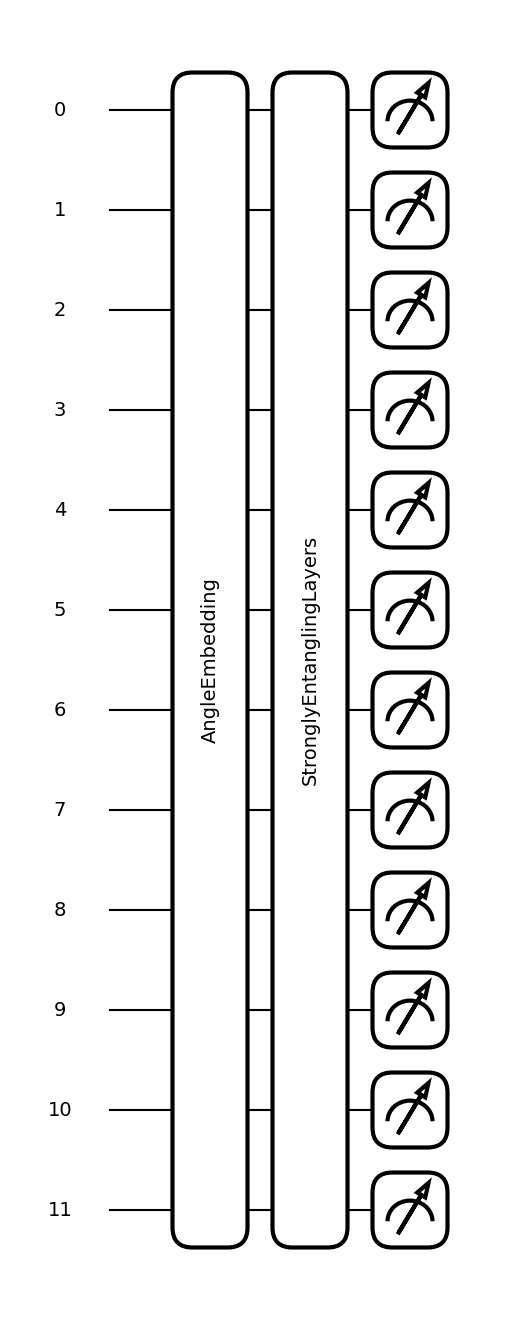

In [1]:
import pennylane as qml
import torch
import numpy as np

# 1. Setup matching your model
n_qubits = 12
n_layers = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(inputs, weights):
    # This is how your CAPTCHA data enters the Quantum world
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    # These are the "Strongly Entangling" layers (the trainable part)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    
    # Measuring the Z-axis of every qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# 2. Generate dummy data to fill the "slots"
dummy_inputs = np.random.uniform(0, np.pi, n_qubits)
dummy_weights = np.random.uniform(0, np.pi, (n_layers, n_qubits, 3))

# 3. Draw the circuit
print("--- 12-QUBIT QML CIRCUIT DIAGRAM ---")
print(qml.draw_mpl(circuit)(dummy_inputs, dummy_weights))

✅ High-res PDF saved as 'transpiled_quantum_circuit.pdf'


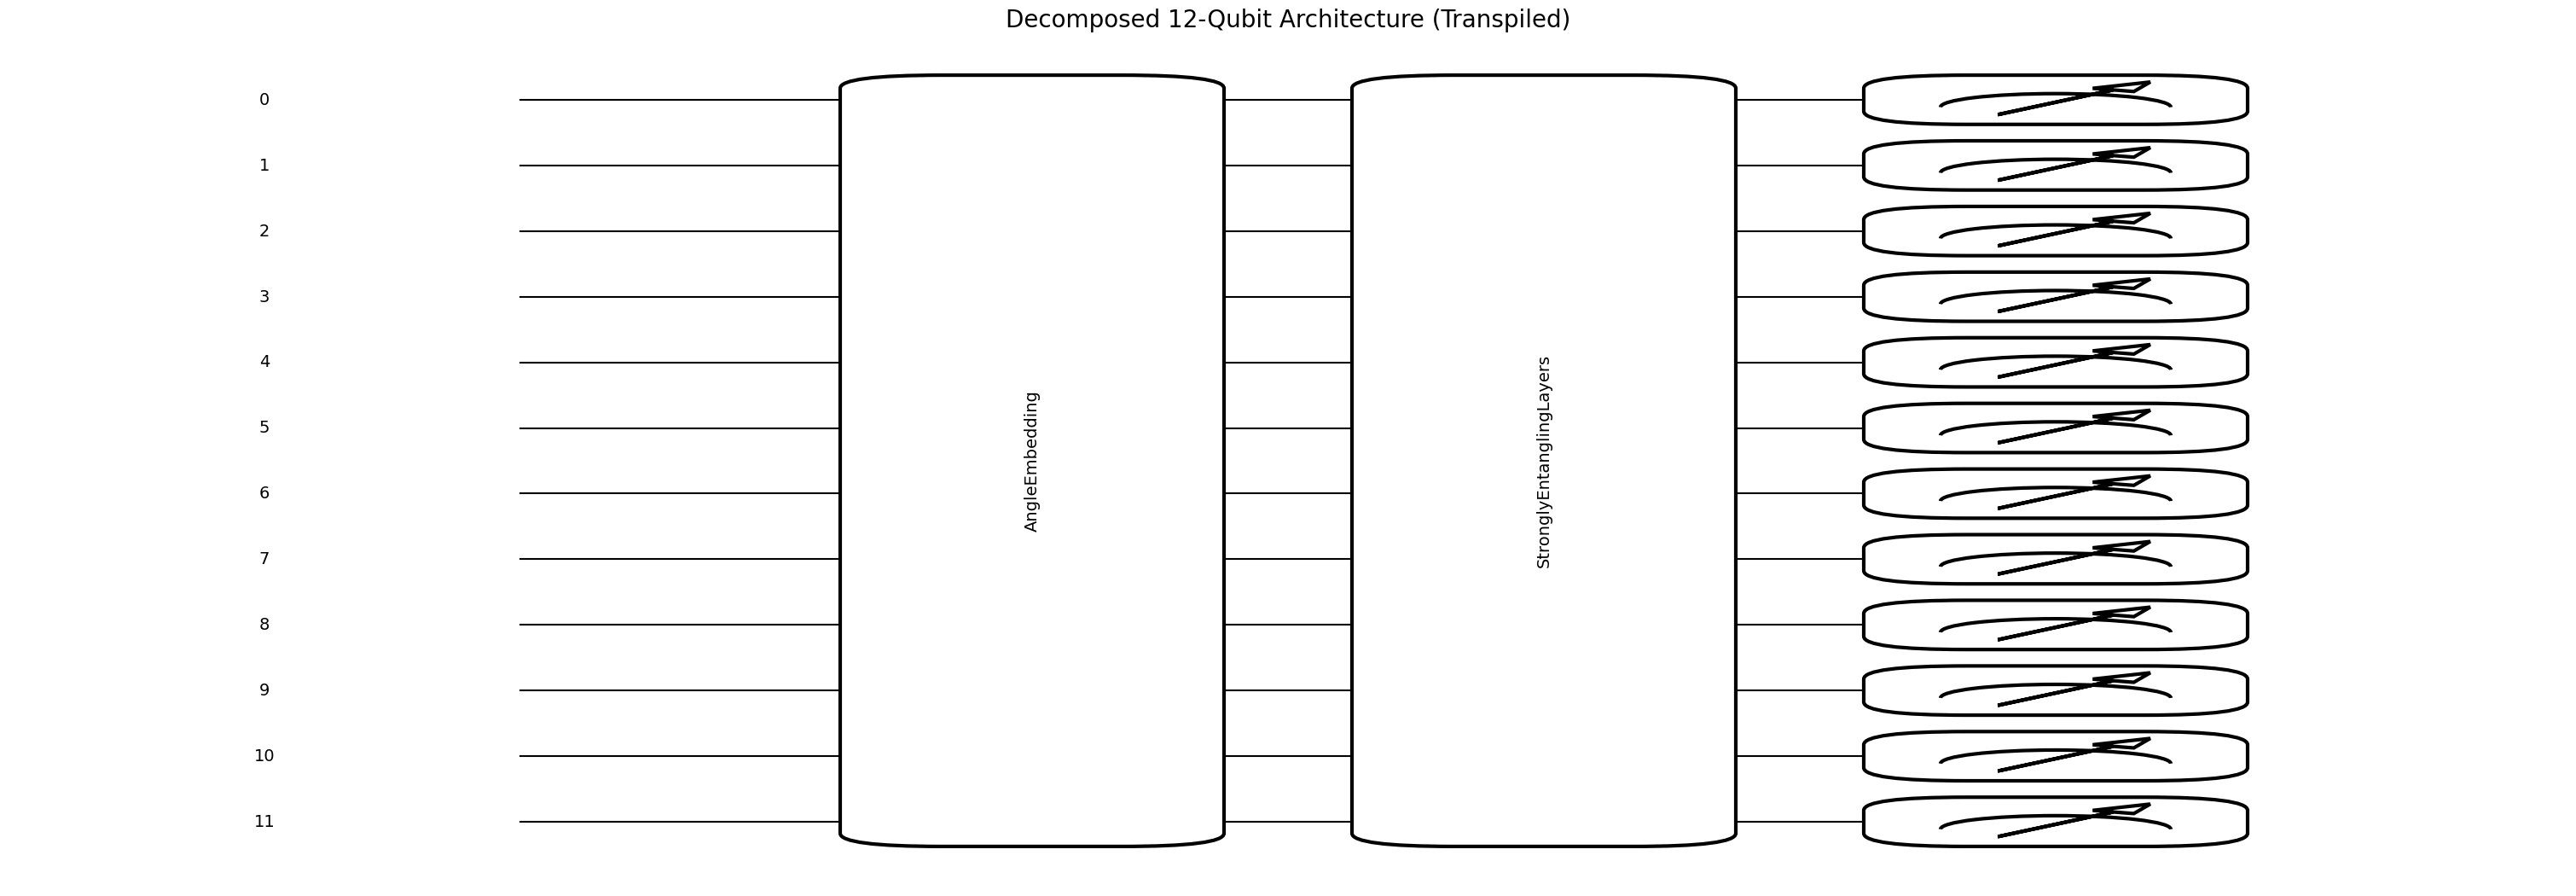

In [2]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup (Exact same as your model)
n_qubits = 12
n_layers = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# 2. Dummy Data
dummy_inputs = np.random.uniform(0, np.pi, n_qubits)
dummy_weights = np.random.uniform(0, np.pi, (n_layers, n_qubits, 3))

# 3. Draw Transpiled (Expansion Strategy is key here)
# We save as PDF because a PNG will likely be too blurry to read at this scale
fig, ax = qml.draw_mpl(circuit, expansion_strategy="device", decimals=1)(dummy_inputs, dummy_weights)

# Make the figure very wide to accommodate the gate chains
fig.set_size_inches(30, 10) 

plt.title("Decomposed 12-Qubit Architecture (Transpiled)", fontsize=20)
plt.savefig("transpiled_quantum_circuit.pdf", bbox_inches='tight')
print("✅ High-res PDF saved as 'transpiled_quantum_circuit.pdf'")
plt.show()

✅ Fully decomposed image saved as 'quantum_gates_unrolled.png'


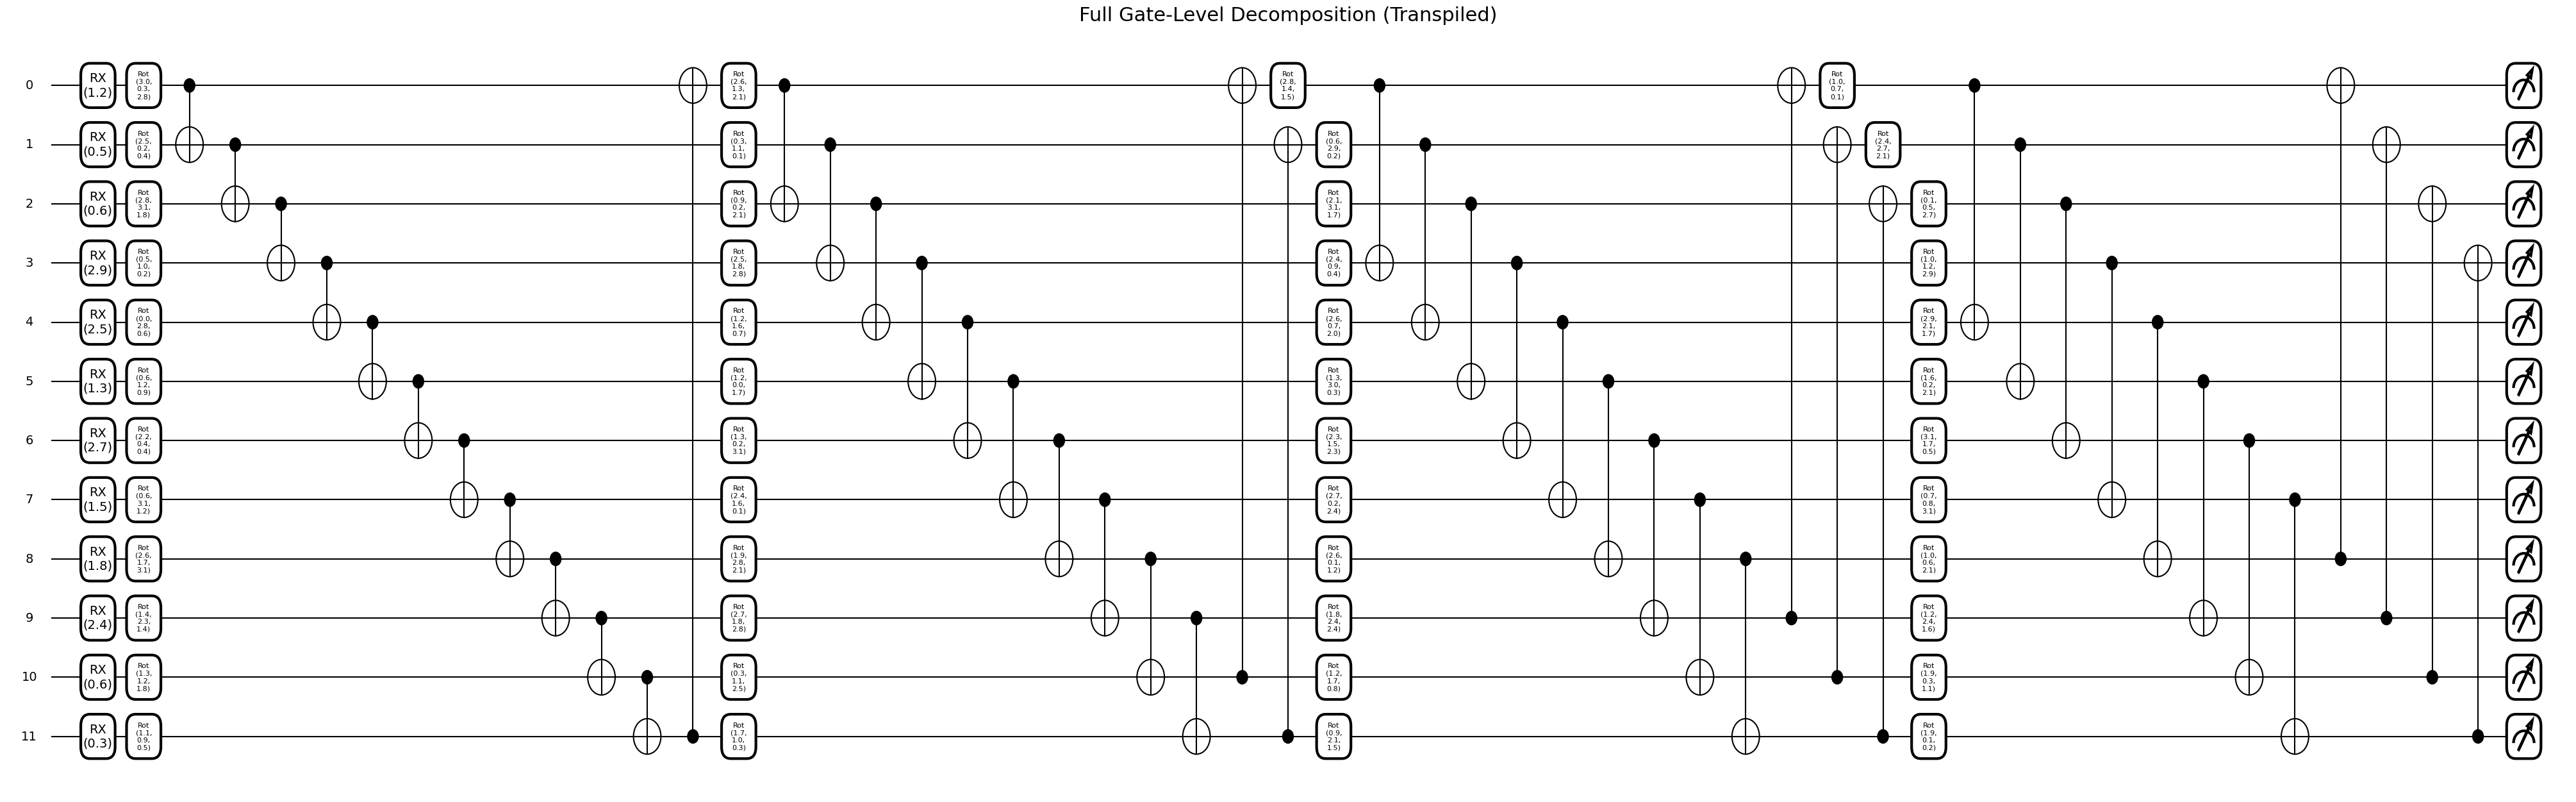

In [3]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup
n_qubits = 12
n_layers = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# 2. Dummy Data
dummy_inputs = np.random.uniform(0, np.pi, n_qubits)
dummy_weights = np.random.uniform(0, np.pi, (n_layers, n_qubits, 3))

# 3. Force Decomposition
# We apply the decompose transform to see the "guts" of the templates
decomposed_circuit = qml.transforms.decompose(circuit)

# 4. Draw with high expansion
fig, ax = qml.draw_mpl(decomposed_circuit, decimals=1)(dummy_inputs, dummy_weights)

# This needs to be VERY wide to be readable
fig.set_size_inches(40, 12) 

plt.title("Full Gate-Level Decomposition (Transpiled)", fontsize=22)
plt.savefig("quantum_gates_unrolled.png", bbox_inches='tight', dpi=300)
print("✅ Fully decomposed image saved as 'quantum_gates_unrolled.png'")
plt.show()

In [5]:
import os
import cv2
import torch
import numpy as np
import random
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import torch.nn as nn

# 1. Setup
n_qubits = 12
device = torch.device("cpu") # We'll do the extraction on CPU for simplicity
checkpoint_path = "qml_best.pth"

# 2. Re-create the Encoder (Flattened to match your checkpoint keys)
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        # We define the layers directly as 'self.layers' but we'll 
        # map them carefully in the next step.
        self.layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, n_qubits)
        )

    def forward(self, x):
        # We use tanh to squash values to [-1, 1] for AngleEmbedding
        return torch.tanh(self.layers(x)) * np.pi

# 3. Load weights with the correct mapping
encoder = Encoder()
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

# This line ensures 'encoder.0.weight' from your file becomes 'layers.0.weight' in this script
new_state_dict = {}
for k, v in checkpoint['model_state_dict'].items():
    if k.startswith("encoder."):
        new_key = k.replace("encoder.", "layers.")
        new_state_dict[new_key] = v

encoder.load_state_dict(new_state_dict)
q_weights = checkpoint['model_state_dict']['q_weights'].numpy()
encoder.eval() # Set to evaluation mode (crucial for BatchNorm)

# 4. Pick a random image
data_dir = "Large_Captcha_Dataset"
img_name = random.choice(os.listdir(data_dir))
img_path = os.path.join(data_dir, img_name)
print(f"📸 Selected Image: {img_name}")

# Preprocess: Just take the FIRST character for the test
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
h, w = img.shape
char_img = img[:, :w//5] # Slice first character
char_img = cv2.resize(char_img, (32, 32))
input_tensor = torch.from_numpy(char_img).float().unsqueeze(0).unsqueeze(0) / 255.0

# 5. Get the 12 "Quantum Angles" from the CNN
with torch.no_grad():
    quantum_inputs = encoder(input_tensor).squeeze().numpy()

# 6. Build the Qiskit Circuit
qc = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    qc.rx(quantum_inputs[i], i)

for layer in range(4):
    for i in range(n_qubits):
        qc.u(*q_weights[layer][i], i)
    for i in range(n_qubits):
        qc.cx(i, (i + 1) % n_qubits)

qc.measure_all()

# 7. Run Simulator
sim = AerSimulator()
result = sim.run(qc, shots=2048).result()
counts = result.get_counts()

# 8. Convert to Expectation Values (The "Answer")
expectations = np.zeros(n_qubits)
for bitstring, count in counts.items():
    bits = list(bitstring[::-1])
    for i in range(n_qubits):
        expectations[i] += count if bits[i] == '0' else -count
final_features = expectations / 2048

print("\n--- RESULTS ---")
print(f"Target Character: {img_name[0]}")
print(f"Top Bitstring: {max(counts, key=counts.get)}")
print(f"Quantum Feature Vector (12 numbers):\n{final_features.round(3)}")

📸 Selected Image: wE2Ws.png

--- RESULTS ---
Target Character: w
Top Bitstring: 011010110101
Quantum Feature Vector (12 numbers):
[-0.334  0.01  -0.034  0.695 -0.334 -0.01   0.995 -0.695  0.334 -0.034
 -1.     0.695]
